# Cargar dataset z64

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd

path = "/content/drive/MyDrive/BCAM/distr_sol_pv_segm_embeddings_v2.npz"

data = np.load(path, allow_pickle=True)

X = data["features"].astype(np.float32)
y = data["label"].astype(int)

print("X:", X.shape)
print("y:", y.shape)

pd.Series(y).value_counts()

Mounted at /content/drive
X: (20976, 64)
y: (20976,)


,count
1,10683
0,10293


# Train / Validation / Test Split

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(14683, 64)
(3146, 64)
(3147, 64)


# Estandarización del espacio latente z64

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)

(14683, 64)


# Configuración PyTorch

In [4]:
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cuda


# DataLoader para entrenamiento del Autoencoder

In [5]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

batch_size = 256

train_ds = TensorDataset(
    torch.tensor(X_train_scaled,dtype=torch.float32)
)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True
)

# Arquitectura del Autoencoder Lineal

In [6]:
class LinearAE(nn.Module):

    def __init__(self, latent_dim):

        super().__init__()

        self.encoder = nn.Linear(64, latent_dim)

        self.decoder = nn.Linear(latent_dim, 64)

    def forward(self,x):

        z = self.encoder(x)

        x_hat = self.decoder(z)

        return x_hat

# Función de entrenamiento del Autoencoder

In [7]:
def train_linear_ae(latent_dim):

    model = LinearAE(latent_dim).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    criterion = nn.MSELoss()

    epochs = 100

    for epoch in range(epochs):

        model.train()

        for (xb,) in train_loader:

            xb = xb.to(device)

            optimizer.zero_grad()

            x_hat = model(xb)

            loss = criterion(x_hat, xb)

            loss.backward()

            optimizer.step()

    return model

# Estudio de reconstrucción z64 → AE(k) → z64

In [8]:
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

recon_results_ae = []

for k in tqdm(range(1,65)):

    model = train_linear_ae(k)

    model.eval()

    with torch.no_grad():

        X_test_tensor = torch.tensor(
            X_test_scaled,
            dtype=torch.float32
        ).to(device)

        X_rec = model(X_test_tensor)

        X_rec = X_rec.cpu().numpy()

    mse = mean_squared_error(
        X_test_scaled,
        X_rec
    )

    recon_results_ae.append({
        "AE": k,
        "MSE_test": mse
    })

df_recon_ae = pd.DataFrame(recon_results_ae)

display(df_recon_ae)

  0%|          | 0/64 [00:00<?, ?it/s]

,AE,MSE_test
0,1,0.298666
1,2,0.158733
2,3,0.089305
3,4,0.049121
4,5,0.034356
...,...,...
59,60,0.000334
60,61,0.000317
61,62,0.000338
62,63,0.000286


# Curva de error de reconstrucción

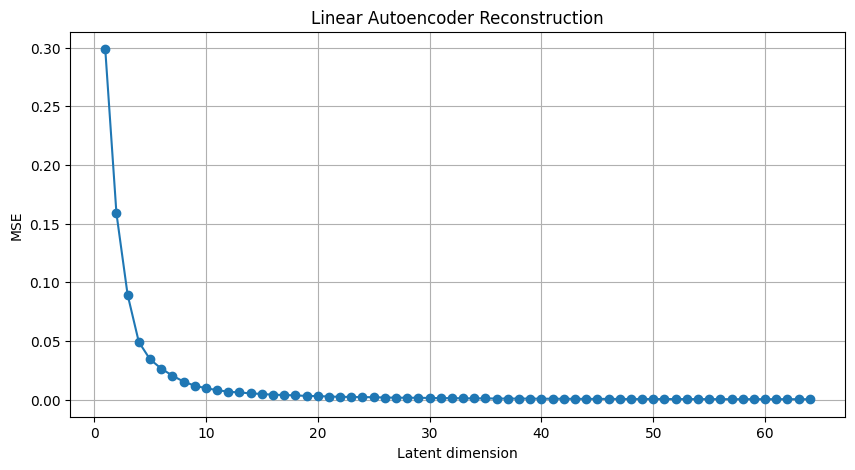

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    df_recon_ae["AE"],
    df_recon_ae["MSE_test"],
    marker="o"
)

plt.xlabel("Latent dimension")
plt.ylabel("MSE")

plt.title("Linear Autoencoder Reconstruction")

plt.grid(True)

plt.show()

# Extracción de embeddings latentes

In [10]:
def extract_embedding(model,X):

    model.eval()

    with torch.no_grad():

        X_tensor = torch.tensor(
            X,
            dtype=torch.float32
        ).to(device)

        Z = model.encoder(X_tensor)

    return Z.cpu().numpy()

# Clasificación SVM-RBF usando embeddings del Autoencoder

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score

results_svm_ae = []

for k in tqdm(range(1,65)):

    model = train_linear_ae(k)

    Z_train = extract_embedding(
        model,
        X_train_scaled
    )

    Z_test = extract_embedding(
        model,
        X_test_scaled
    )

    clf = SVC(
        kernel="rbf",
        probability=False
    )

    clf.fit(
        Z_train,
        y_train
    )

    y_pred = clf.predict(Z_test)

    y_score = clf.decision_function(Z_test)

    results_svm_ae.append({
        "AE": k,
        "Acc": accuracy_score(y_test,y_pred),
        "F1": f1_score(y_test,y_pred),
        "bAcc": balanced_accuracy_score(y_test,y_pred),
        "AUC": roc_auc_score(y_test,y_score)
    })

df_svm_ae = pd.DataFrame(results_svm_ae)

display(df_svm_ae)

display(
    df_svm_ae.loc[
        [df_svm_ae["AUC"].idxmax()]
    ]
)

  0%|          | 0/64 [00:00<?, ?it/s]

,AE,Acc,F1,bAcc,AUC
0,1,0.793772,0.789900,0.794397,0.838734
1,2,0.872259,0.860610,0.874133,0.925253
2,3,0.878297,0.868249,0.880036,0.931095
3,4,0.880521,0.870434,0.882291,0.932659
4,5,0.887830,0.878985,0.889513,0.935422
...,...,...,...,...,...
59,60,0.894185,0.886927,0.895703,0.937029
60,61,0.892596,0.885112,0.894132,0.937750
61,62,0.892914,0.885491,0.894444,0.937768
62,63,0.893549,0.886171,0.895079,0.936813


,AE,Acc,F1,bAcc,AUC
38,39,0.894185,0.886927,0.895703,0.937998


# Clasificación Random Forest usando embeddings del Autoencoder

In [12]:
from sklearn.ensemble import RandomForestClassifier

results_rf_ae = []

for k in tqdm(range(1,65)):

    model = train_linear_ae(k)

    Z_train = extract_embedding(
        model,
        X_train_scaled
    )

    Z_test = extract_embedding(
        model,
        X_test_scaled
    )

    clf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    clf.fit(
        Z_train,
        y_train
    )

    y_pred = clf.predict(Z_test)

    y_prob = clf.predict_proba(Z_test)[:,1]

    results_rf_ae.append({
        "AE": k,
        "Acc": accuracy_score(y_test,y_pred),
        "F1": f1_score(y_test,y_pred),
        "bAcc": balanced_accuracy_score(y_test,y_pred),
        "AUC": roc_auc_score(y_test,y_prob)
    })

df_rf_ae = pd.DataFrame(results_rf_ae)

display(df_rf_ae)

display(
    df_rf_ae.loc[
        [df_rf_ae["AUC"].idxmax()]
    ]
)

  0%|          | 0/64 [00:00<?, ?it/s]

,AE,Acc,F1,bAcc,AUC
0,1,0.706705,0.709108,0.706798,0.806431
1,2,0.859231,0.854897,0.860093,0.925101
2,3,0.876708,0.872787,0.877594,0.934171
3,4,0.880203,0.875207,0.881264,0.935359
4,5,0.886241,0.880826,0.887405,0.939642
...,...,...,...,...,...
59,60,0.893232,0.887625,0.894481,0.946655
60,61,0.892914,0.887329,0.894158,0.945579
61,62,0.894820,0.889850,0.895981,0.948028
62,63,0.892914,0.887479,0.894134,0.948431


,AE,Acc,F1,bAcc,AUC
32,33,0.891961,0.88644,0.893186,0.948797


# Clasificación Logistic Regression usando embeddings del Autoencoder

In [13]:
from sklearn.linear_model import LogisticRegression

results_lr_ae = []

for k in tqdm(range(1,65)):

    model = train_linear_ae(k)

    Z_train = extract_embedding(
        model,
        X_train_scaled
    )

    Z_test = extract_embedding(
        model,
        X_test_scaled
    )

    clf = LogisticRegression(
        max_iter=5000
    )

    clf.fit(
        Z_train,
        y_train
    )

    y_pred = clf.predict(Z_test)

    y_prob = clf.predict_proba(Z_test)[:,1]

    results_lr_ae.append({
        "AE": k,
        "Acc": accuracy_score(y_test,y_pred),
        "F1": f1_score(y_test,y_pred),
        "bAcc": balanced_accuracy_score(y_test,y_pred),
        "AUC": roc_auc_score(y_test,y_prob)
    })

df_lr_ae = pd.DataFrame(results_lr_ae)

display(df_lr_ae)

display(
    df_lr_ae.loc[
        [df_lr_ae["AUC"].idxmax()]
    ]
)

  0%|          | 0/64 [00:00<?, ?it/s]

,AE,Acc,F1,bAcc,AUC
0,1,0.794407,0.786539,0.795378,0.873493
1,2,0.872259,0.863729,0.873740,0.917486
2,3,0.886241,0.879299,0.887631,0.933315
3,4,0.886876,0.879892,0.888279,0.931590
4,5,0.891007,0.884317,0.892405,0.943669
...,...,...,...,...,...
59,60,0.893867,0.888145,0.895141,0.947863
60,61,0.893867,0.887995,0.895165,0.948376
61,62,0.893867,0.887995,0.895165,0.947970
62,63,0.894503,0.888889,0.895765,0.948050


,AE,Acc,F1,bAcc,AUC
32,33,0.896727,0.890903,0.898044,0.949115


# Consolidación de resultados

In [14]:
df_all_ae = pd.concat(
    [
        df_svm_ae,
        df_rf_ae,
        df_lr_ae
    ],
    ignore_index=True
)

display(df_all_ae)

,AE,Acc,F1,bAcc,AUC
0,1,0.793772,0.789900,0.794397,0.838734
1,2,0.872259,0.860610,0.874133,0.925253
2,3,0.878297,0.868249,0.880036,0.931095
3,4,0.880521,0.870434,0.882291,0.932659
4,5,0.887830,0.878985,0.889513,0.935422
...,...,...,...,...,...
187,60,0.893867,0.888145,0.895141,0.947863
188,61,0.893867,0.887995,0.895165,0.948376
189,62,0.893867,0.887995,0.895165,0.947970
190,63,0.894503,0.888889,0.895765,0.948050


# Comparación de AUC según dimensión latente

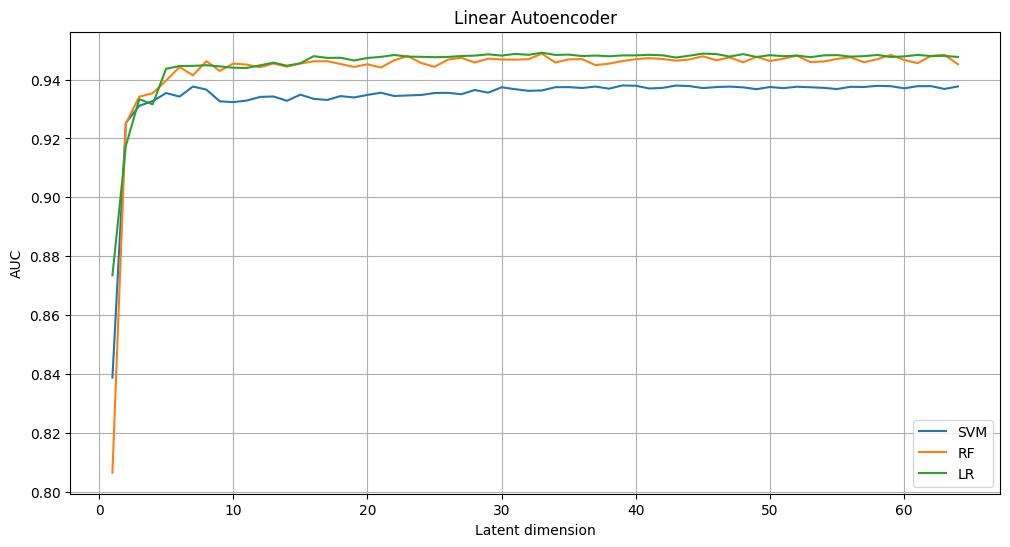

In [15]:
plt.figure(figsize=(12,6))

plt.plot(
    df_svm_ae["AE"],
    df_svm_ae["AUC"],
    label="SVM"
)

plt.plot(
    df_rf_ae["AE"],
    df_rf_ae["AUC"],
    label="RF"
)

plt.plot(
    df_lr_ae["AE"],
    df_lr_ae["AUC"],
    label="LR"
)

plt.xlabel("Latent dimension")
plt.ylabel("AUC")
plt.title("Linear Autoencoder")

plt.grid(True)
plt.legend()

plt.show()

In [16]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print("df_recon_ae:\n", df_recon_ae.to_string())
print("\ndf_svm_ae:\n", df_svm_ae.to_string())
print("\ndf_rf_ae:\n", df_rf_ae.to_string())
print("\ndf_lr_ae:\n", df_lr_ae.to_string())
print("\ndf_all_ae:\n", df_all_ae.to_string())

df_recon_ae:
     AE  MSE_test
0    1  0.298666
1    2  0.158733
2    3  0.089305
3    4  0.049121
4    5  0.034356
5    6  0.026445
6    7  0.020412
7    8  0.015330
8    9  0.011824
9   10  0.009659
10  11  0.008055
11  12  0.006659
12  13  0.006069
13  14  0.005271
14  15  0.004782
15  16  0.004107
16  17  0.003899
17  18  0.003530
18  19  0.003117
19  20  0.002937
20  21  0.002596
21  22  0.002331
22  23  0.002231
23  24  0.002085
24  25  0.001989
25  26  0.001748
26  27  0.001609
27  28  0.001551
28  29  0.001519
29  30  0.001355
30  31  0.001229
31  32  0.001225
32  33  0.001059
33  34  0.000999
34  35  0.001022
35  36  0.000850
36  37  0.000872
37  38  0.000821
38  39  0.000848
39  40  0.000720
40  41  0.000719
41  42  0.000658
42  43  0.000625
43  44  0.000579
44  45  0.000568
45  46  0.000570
46  47  0.000510
47  48  0.000476
48  49  0.000497
49  50  0.000467
50  51  0.000432
51  52  0.000412
52  53  0.000413
53  54  0.000389
54  55  0.000382
55  56  0.000367
56  57  0.000317
